# Qwen3-8B — Hypothesis 1 And Concept-Copying Analysis

Mirror of `result_analysis.ipynb` for Qwen3-8B. It loads:

- `cache/improbable_bigrams/Qwen3-8B/updated_table1_literal/` — improbable bigrams (65 tasks ported from `llama3.1_tasks.json`)
- `cache/improbable_bigrams/Qwen3-8B/selected_two_token_concepts/` — coherent 2-token concept control (36 tasks)
- `cache/improbable_bigrams/Qwen3-8B/random_tokens/` — random two-token phrase control (35 tasks)
- `cache/causal_scores/Qwen3-8B/{concept_copying,token_copying}_len30_n1024.json` — head rankings (Section 2)

Plotting / scoring functions in `analysis_utils` are model-agnostic, so the cells below are identical to `result_analysis.ipynb` apart from `model_name="Qwen3-8B"` and the figure save dirs (`qwen_hypothesis1_figures/`, `qwen_concept_head_figures/`).

In [17]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    candidates = []
    for candidate in (start, *start.parents):
        candidates.extend(
            [
                candidate,
                candidate / "dual-route-induction",
                candidate / "improbable-bigram-causality" / "dual-route-induction",
            ]
        )
    for candidate in candidates:
        if (candidate / "cache").exists() and (candidate / "scripts").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate the dual-route-induction repo root from the current working directory."
    )


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

import analysis_utils as h1

h1 = importlib.reload(h1)

h1.configure_matplotlib()
CACHE = h1.load_cache(ROOT, model_name="Qwen3-8B")
DEFAULT_TOP_K = 32
ROOT

PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction')

## Shared Cache Checks

Verify that the traced cache and both control caches are available before either analysis section.

In [18]:
display(Markdown(h1.trace_consistency_markdown(CACHE)))
overview = h1.dataset_overview(CACHE)
display(overview)

### Trace Consistency
The prompt-summary JSON is not present in this repo snapshot. The notebook therefore uses the traced cache directly.

,dataset,examples,hallucinated_second_token,copied
0,Improbable summary,85,29,56
1,Updated trace cache,85,29,56
2,2-token concept cache,36,0,36
3,Random phrase cache,35,0,35


# Hypothesis 1 Analysis

Token-induction diagnostics for Qwen3-8B on the improbable-bigram repetition setup:

- token induction heads should keep attending to the desired earlier suffix token, measured with `NTM`
- token induction heads should keep contributing to the correct second-token prediction, measured with `DLA`

Improbable trace lives in `updated_table1_literal/`; controls in `selected_two_token_concepts/` and `random_tokens/`.

In [19]:
summary = h1.build_pairwise_summary(CACHE, DEFAULT_TOP_K)
display(summary.round(6))
display(Markdown(h1.interpretation_markdown(CACHE, DEFAULT_TOP_K)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Token NTM (raw),Hallucinated - Copied,0.196532,0.267462,-0.070930,-0.093169,-0.047748
1,Token NTM (raw),Hallucinated - 2-token concepts,0.196532,0.211088,-0.014557,-0.035737,0.008079
2,Token NTM (raw),Hallucinated - Random,0.196532,0.238851,-0.042319,-0.071643,-0.013814
3,Token NTM (value-weighted),Hallucinated - Copied,0.385342,0.472143,-0.086801,-0.113488,-0.058207
4,Token NTM (value-weighted),Hallucinated - 2-token concepts,0.385342,0.322693,0.062649,0.032438,0.094490
5,Token NTM (value-weighted),Hallucinated - Random,0.385342,0.369240,0.016102,-0.022942,0.053674
6,Token correct-token DLA,Hallucinated - Copied,0.061744,0.057434,0.004310,-0.004577,0.013931
7,Token correct-token DLA,Hallucinated - 2-token concepts,0.061744,0.211837,-0.150093,-0.171993,-0.127931
8,Token correct-token DLA,Hallucinated - Random,0.061744,0.178966,-0.117222,-0.150459,-0.087335
9,Hallucinated token DLA,Wrong-token - Correct-token,0.039498,0.061744,-0.022246,-0.034693,-0.010869


### Hypothesis 1 Readout at Top-32
- Hallucinated vs copied NTM: `-0.0709` (95% CI `-0.0932` to `-0.0477`)
- Hallucinated vs copied correct-token DLA: `0.0043` (95% CI `-0.0046` to `0.0139`)
- Hallucinated vs 2-token concepts NTM: `-0.0146` (95% CI `-0.0357` to `0.0081`)
- Hallucinated vs 2-token concepts correct-token DLA: `-0.1501` (95% CI `-0.1720` to `-0.1279`)
- Hallucinated vs random NTM: `-0.0423` (95% CI `-0.0716` to `-0.0138`)
- Hallucinated vs random correct-token DLA: `-0.1172` (95% CI `-0.1505` to `-0.0873`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0222` (95% CI `-0.0347` to `-0.0109`)

Within the improbable-bigram set, the traced cache does not show a clear hallucination-specific token-head breakdown. The stronger claim that token-head behavior is similar across all conditions is harder to defend, because the 2-token concept and random-phrase controls are both stronger on the token-head metrics.

,metric,condition,k,mean,ci_low,ci_high
0,Token NTM (raw),Hallucinated improbable,8,0.459614,0.424350,0.497695
1,Token NTM (raw),Copied improbable,8,0.580638,0.557954,0.601925
2,Token NTM (raw),2-token concepts,8,0.378088,0.349934,0.404615
3,Token NTM (raw),Random phrases,8,0.420750,0.384478,0.457076
4,Token NTM (raw),Hallucinated improbable,16,0.275871,0.256276,0.297516
5,Token NTM (raw),Copied improbable,16,0.330480,0.317518,0.343194
6,Token NTM (raw),2-token concepts,16,0.276158,0.264663,0.286857
7,Token NTM (raw),Random phrases,16,0.304417,0.286708,0.322017
8,Token NTM (raw),Hallucinated improbable,32,0.196532,0.179242,0.215959
9,Token NTM (raw),Copied improbable,32,0.267462,0.253383,0.281048


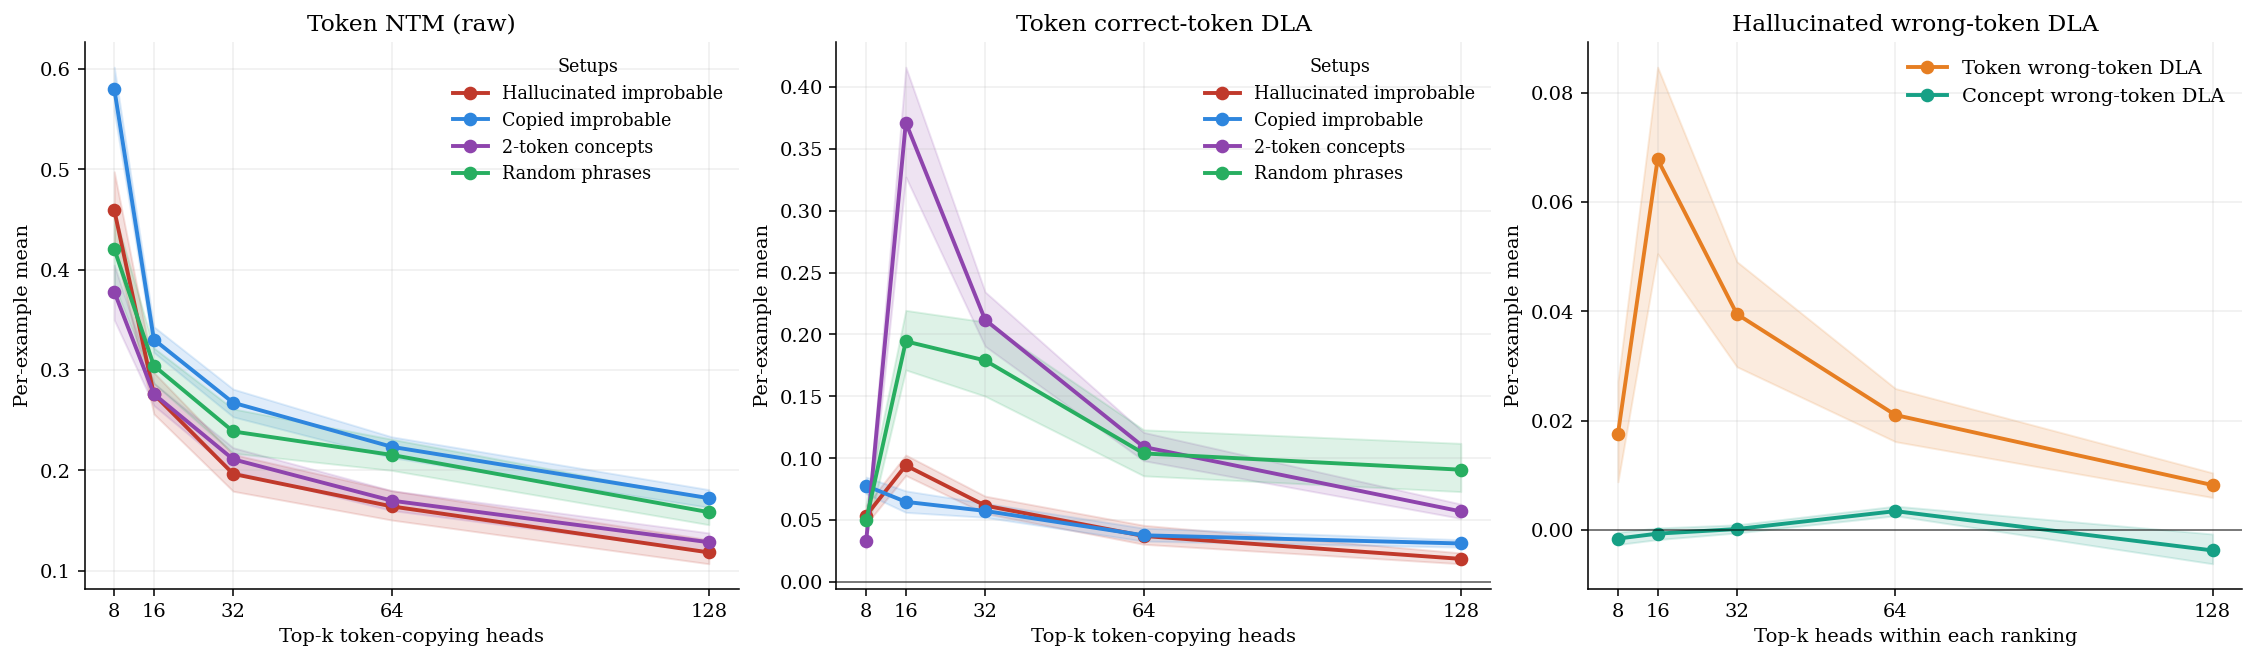

In [20]:
fig, axes, sweep = h1.plot_k_sweep(CACHE, ks=(8, 16, 32, 64, 128))
display(sweep.round(6))

(<Figure size 1680x784 with 2 Axes>,
 array([<Axes: title={'center': 'Top-32 token-head NTM'}, ylabel='Per-example mean'>,
        <Axes: title={'center': 'Top-32 token-head correct-token DLA'}, ylabel='Per-example mean'>],
       dtype=object))

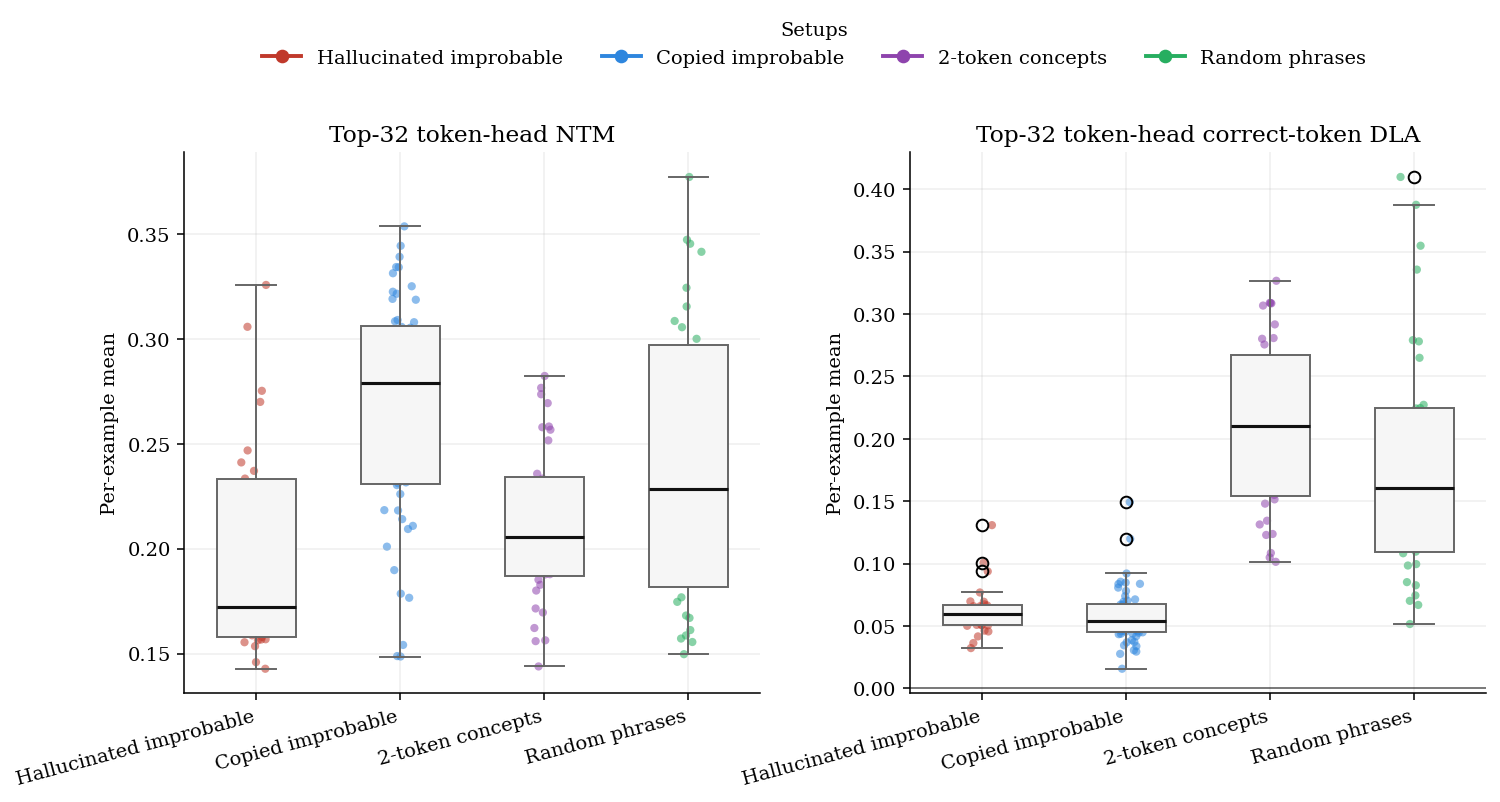

In [21]:
h1.plot_distribution_panels(CACHE, DEFAULT_TOP_K)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 token heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

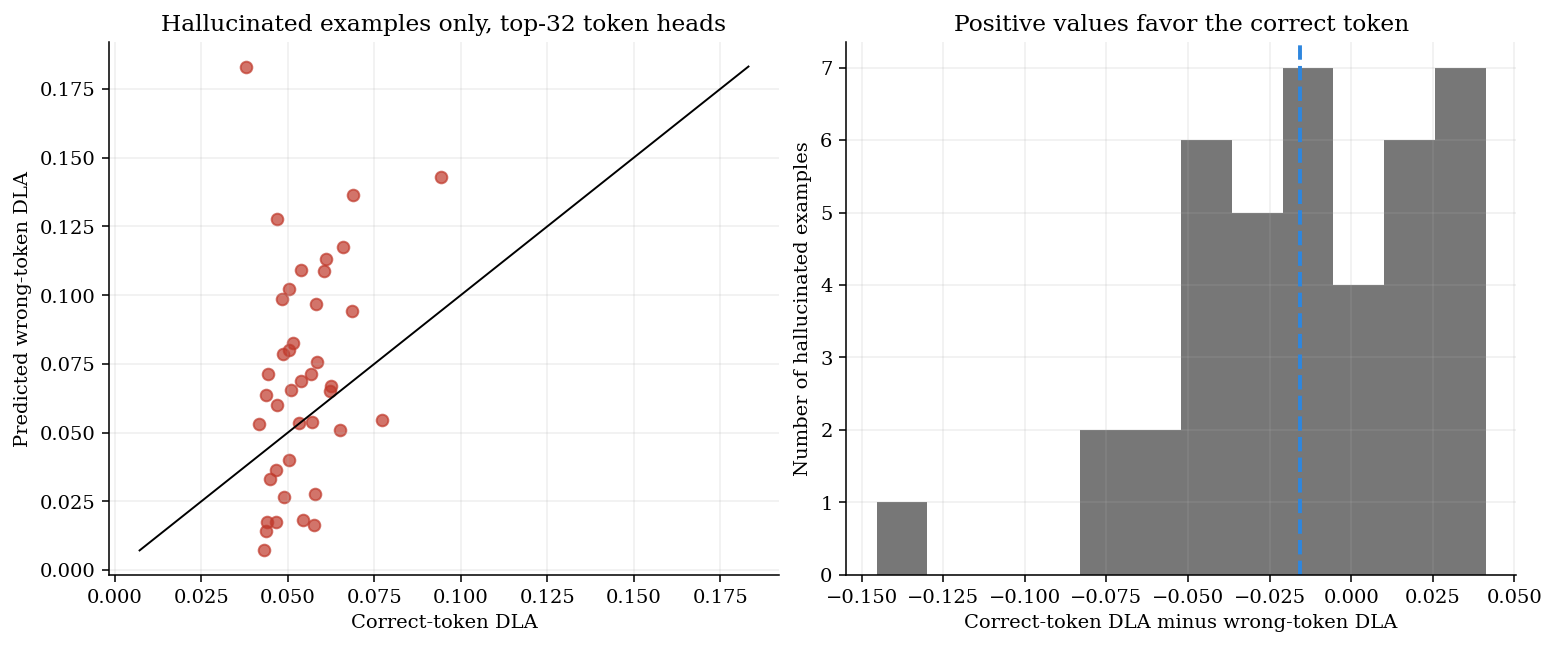

In [7]:
h1.plot_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

(<Figure size 1890x784 with 4 Axes>,
 array([<Axes: title={'center': 'Top-16 token heads: NTM'}>,
        <Axes: title={'center': 'Top-16 token heads: DLA'}>], dtype=object))

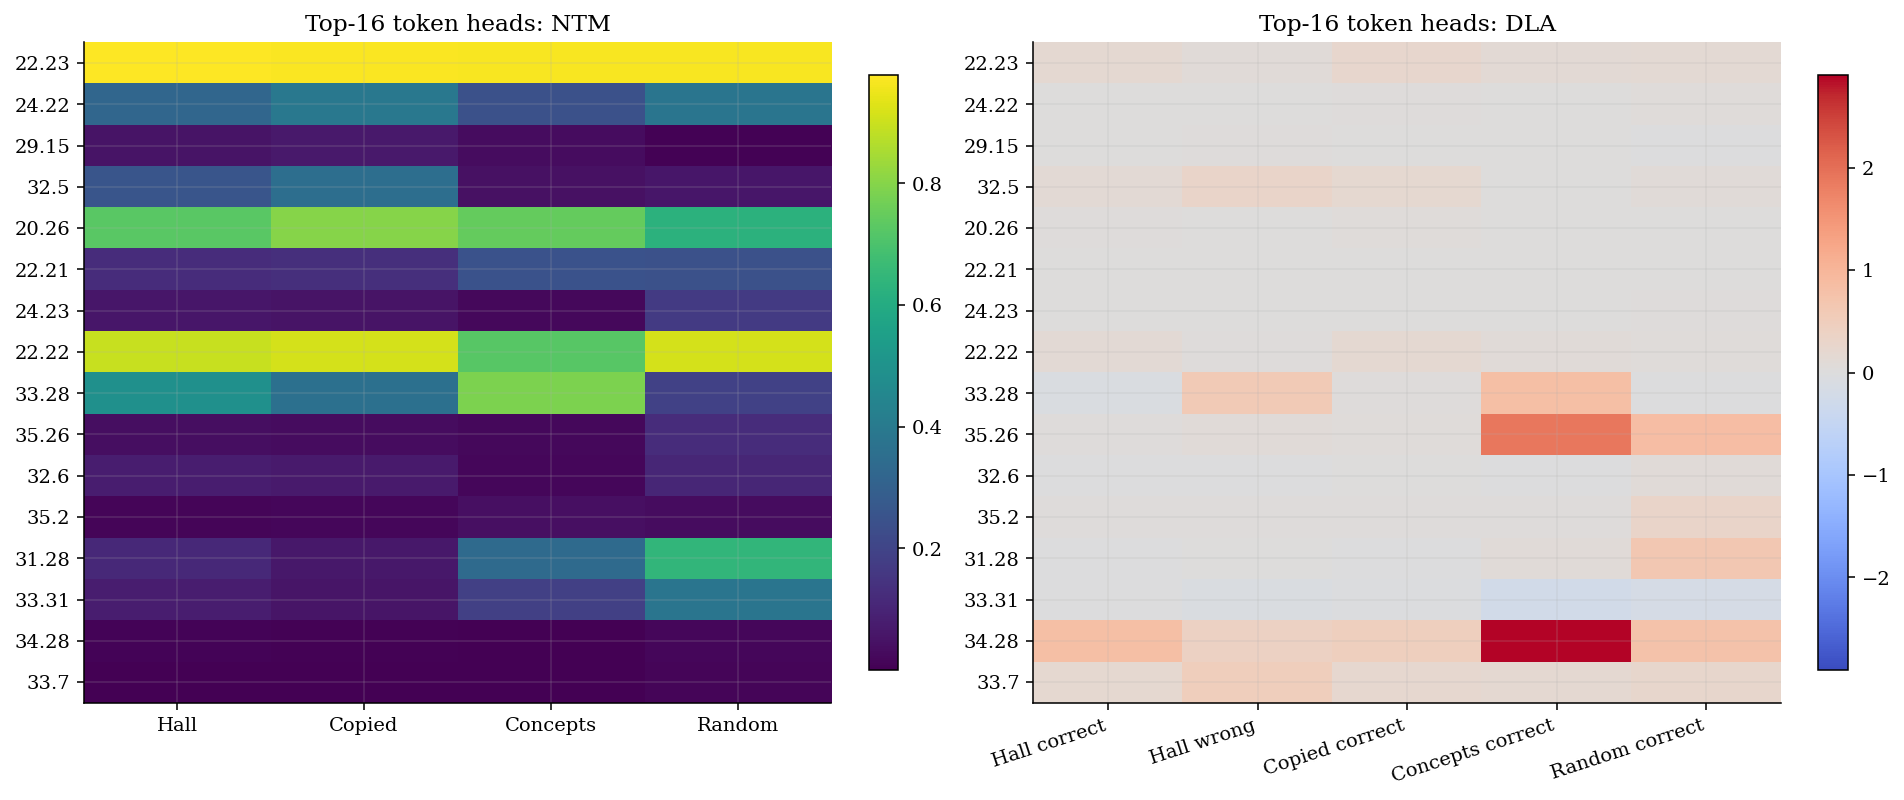

In [11]:
h1.plot_top_head_heatmap(CACHE, top_k=16)

## Are The Highest-DLA Heads Token-Copying Or Concept-Copying?

Rank heads by mean DLA on each example subset and check membership in the token-copying and concept-copying top-K rankings.

In [8]:
TOP_DLA_N = 20
COMPARE_K = 32
SOURCES = [
    "hallucinated_correct",
    "hallucinated_wrong",
    "copied_correct",
    "concepts_correct",
    "random_correct",
]

membership_summary = h1.summarize_top_dla_membership(
    CACHE,
    sources=SOURCES,
    top_n=TOP_DLA_N,
    compare_k=COMPARE_K,
)
display(membership_summary)

for source in SOURCES:
    table = h1.top_dla_membership_table(
        CACHE,
        source=source,
        top_n=TOP_DLA_N,
        compare_k=COMPARE_K,
    )
    display(Markdown(f"### {table['source'].iloc[0]}"))
    display(
        table[
            [
                "head",
                "mean_dla",
                "membership_label",
                "in_token_top_k",
                "in_concept_top_k",
                "token_rank",
                "concept_rank",
            ]
        ].round({"mean_dla": 6})
    )

,source,top_n,compare_k,token_overlap,concept_overlap,both_overlap,neither_overlap,mean_token_rank,mean_concept_rank
0,Hallucinated correct-token DLA,20,32,4,0,0,16,403.85,503.35
1,Hallucinated wrong-token DLA,20,32,4,0,0,16,438.65,560.45
2,Copied-improbable correct-token DLA,20,32,6,0,0,14,392.40,551.70
3,2-token-concept correct-token DLA,20,32,4,0,0,16,489.40,525.55
4,Random-phrase correct-token DLA,20,32,5,0,0,15,326.30,565.25


### Hallucinated correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,34.28,0.834155,Token only,True,False,15,553
1,35.24,0.675104,Neither,False,False,1144,88
2,34.1,0.607638,Neither,False,False,714,1032
3,29.9,0.421763,Neither,False,False,1122,399
4,35.22,0.364851,Neither,False,False,993,112
5,33.16,0.359882,Neither,False,False,57,724
6,32.3,0.355826,Neither,False,False,375,159
7,33.29,0.341326,Neither,False,False,752,976
8,34.3,0.313868,Neither,False,False,111,661
9,35.12,0.311578,Neither,False,False,680,105


### Hallucinated wrong-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,33.28,0.585856,Token only,True,False,9,636
1,33.7,0.494628,Token only,True,False,16,777
2,33.16,0.488944,Neither,False,False,57,724
3,29.9,0.463290,Neither,False,False,1122,399
4,34.28,0.391180,Token only,True,False,15,553
5,34.1,0.325292,Neither,False,False,714,1032
6,32.11,0.313586,Neither,False,False,1034,592
7,34.2,0.312345,Neither,False,False,422,410
8,32.5,0.294984,Token only,True,False,4,572
9,33.29,0.247911,Neither,False,False,752,976


...

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,33.16,0.644751,Neither,False,False,57,724
1,33.29,0.556826,Neither,False,False,752,976
2,34.3,0.549214,Neither,False,False,111,661
3,34.28,0.467467,Token only,True,False,15,553
4,34.1,0.457756,Neither,False,False,714,1032
5,29.9,0.448235,Neither,False,False,1122,399
6,35.24,0.365132,Neither,False,False,1144,88
7,30.6,0.358905,Neither,False,False,342,877
8,29.14,0.264709,Neither,False,False,52,250
9,29.12,0.254538,Neither,False,False,332,307


### 2-token-concept correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,34.28,2.901301,Token only,True,False,15,553
1,35.26,1.903838,Token only,True,False,10,91
2,29.10,0.965084,Neither,False,False,159,644
3,33.28,0.820225,Token only,True,False,9,636
4,35.19,0.801831,Neither,False,False,195,114
5,34.0,0.791210,Neither,False,False,684,656
6,35.16,0.681076,Neither,False,False,353,109
7,32.8,0.660039,Neither,False,False,1031,47
8,33.24,0.589796,Neither,False,False,900,734
9,34.1,0.576459,Neither,False,False,714,1032


### Random-phrase correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,34.3,2.271138,Neither,False,False,111,661
1,33.10,1.798013,Neither,False,False,428,1014
2,34.1,1.676162,Neither,False,False,714,1032
3,33.30,1.365522,Token only,True,False,20,403
4,33.11,1.100477,Neither,False,False,308,310
5,34.17,1.077240,Token only,True,False,22,695
6,32.3,1.059751,Neither,False,False,375,159
7,34.19,1.043126,Neither,False,False,452,124
8,33.12,0.962338,Neither,False,False,179,516
9,35.19,0.911324,Neither,False,False,195,114


PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction/scripts/qwen_hypothesis1_figures')

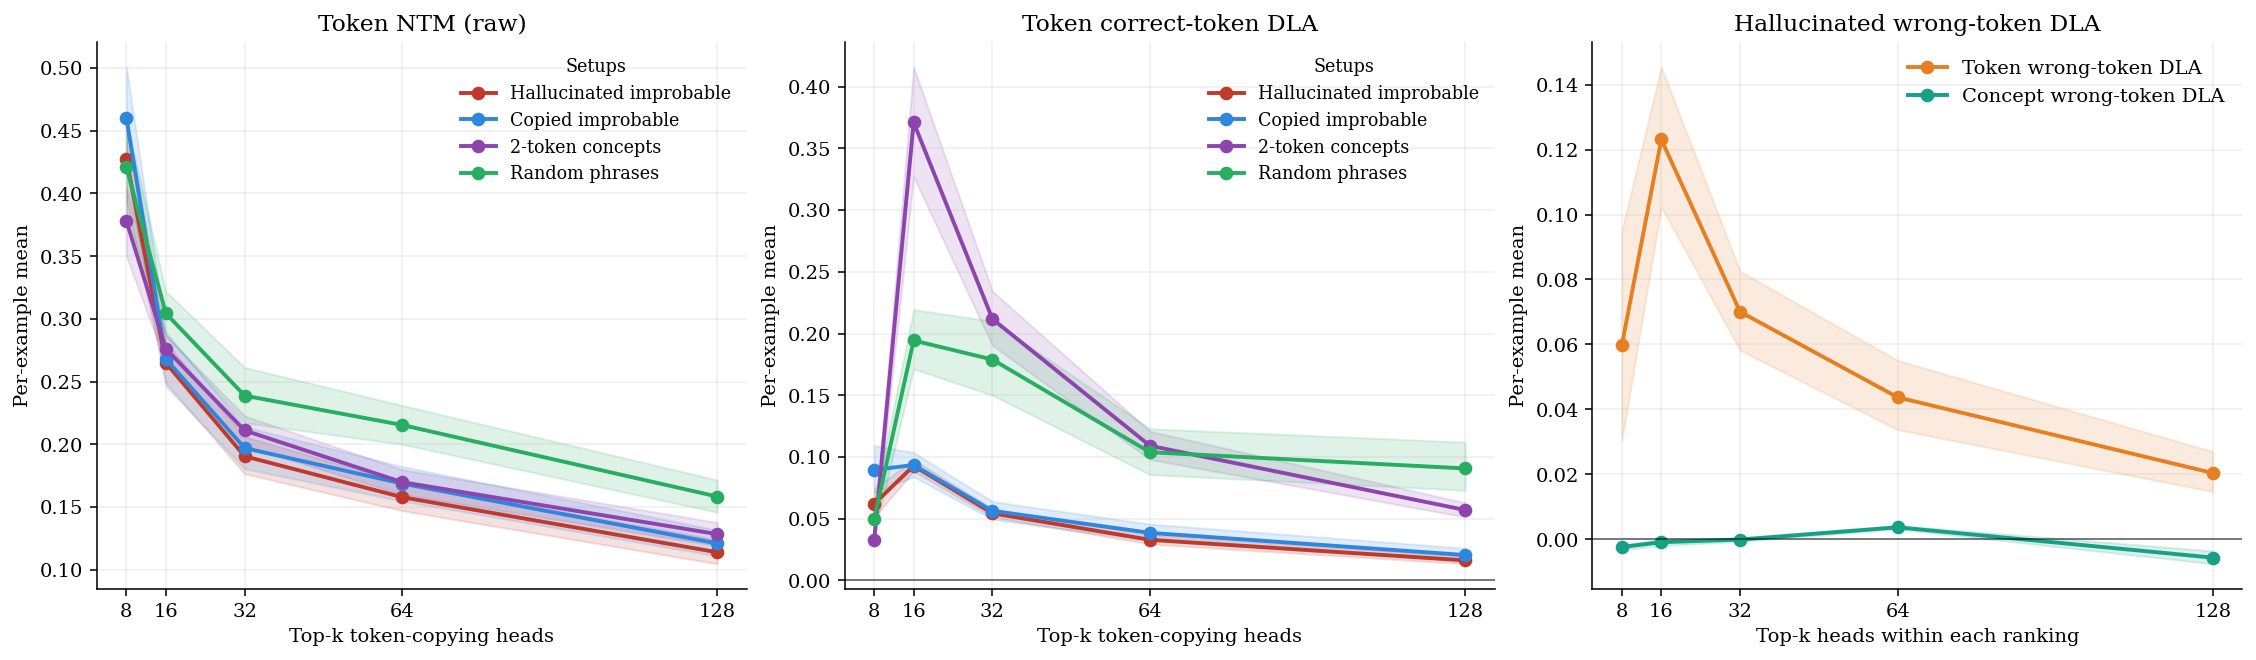

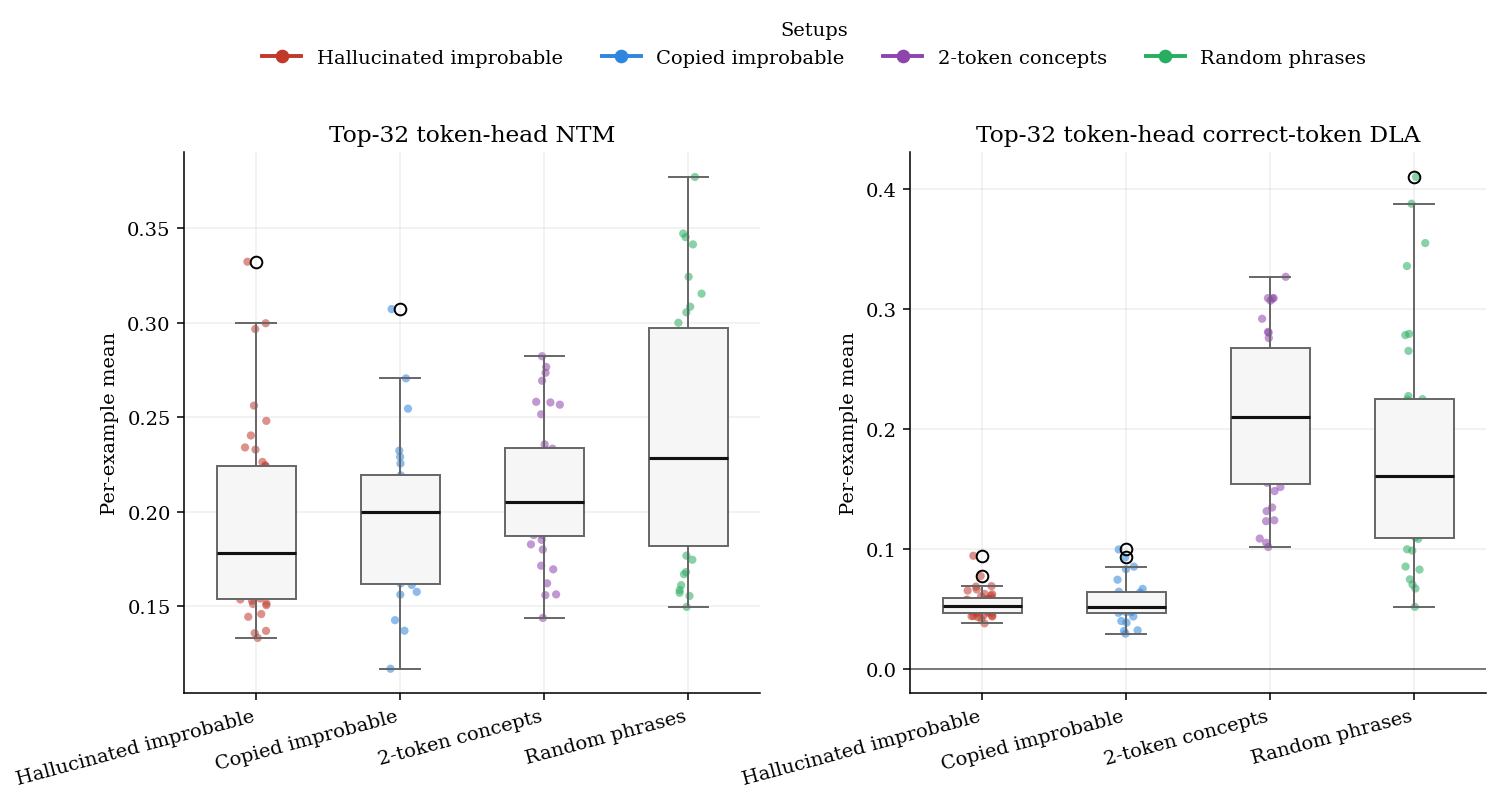

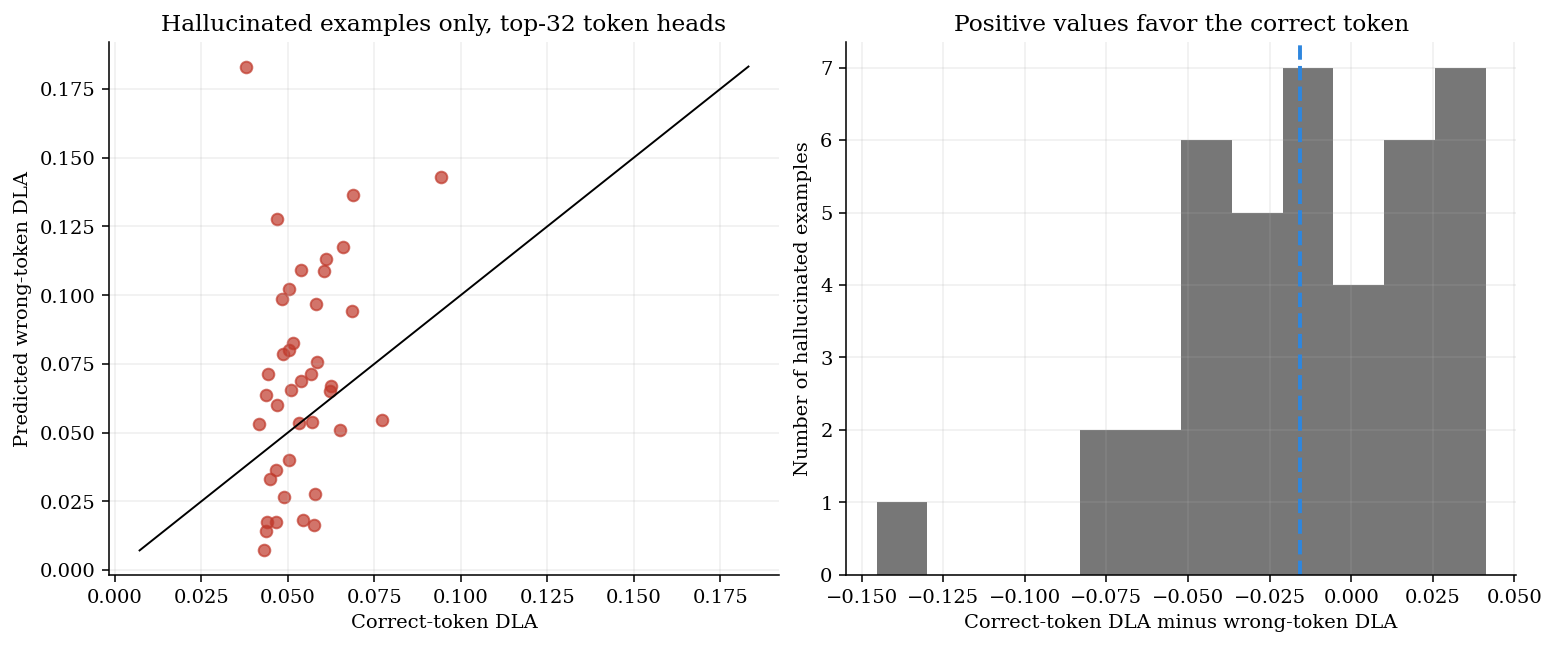

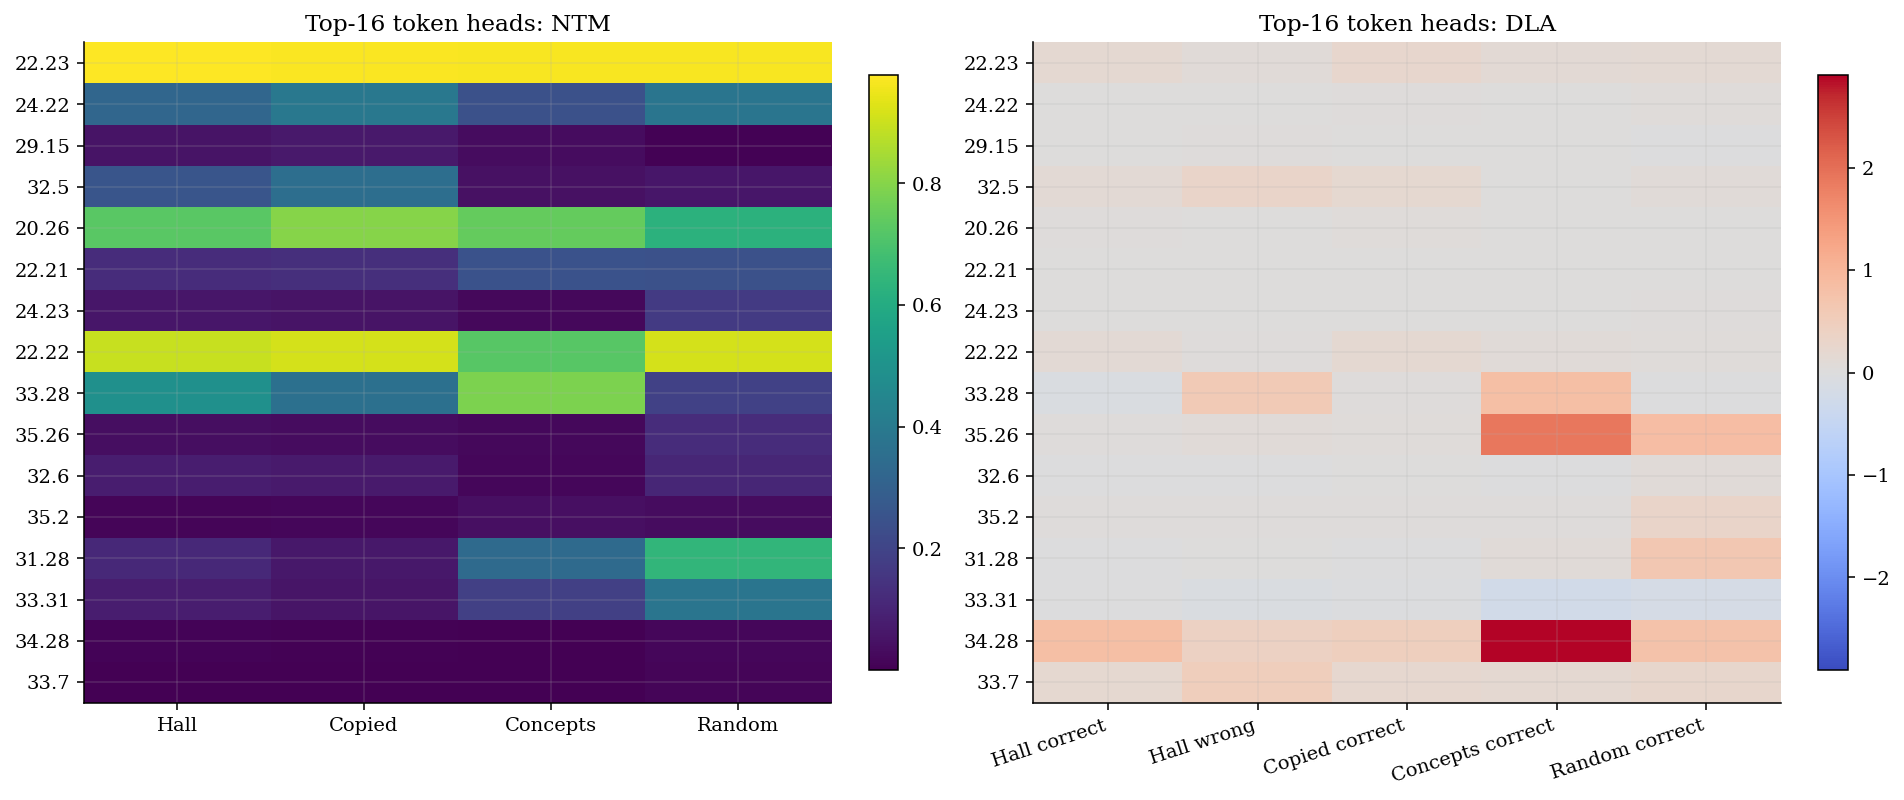

In [9]:
SAVE_DIR = ROOT / "scripts" / "qwen_hypothesis1_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_k_sweep(
    CACHE, ks=(8, 16, 32, 64, 128), save_path=SAVE_DIR / "hypothesis1_k_sweep.png"
)
_ = h1.plot_distribution_panels(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "hypothesis1_distributions.png"
)
_ = h1.plot_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "hypothesis1_hallucinated_dla_pair.png"
)
_ = h1.plot_top_head_heatmap(
    CACHE, top_k=16, save_path=SAVE_DIR / "hypothesis1_top_token_heads.png"
)
SAVE_DIR

---

# Concept-Copying Head Analysis

Mirrors `concept_copying_analysis.ipynb`. Reuses the same loaded cache and helper module.

## Coverage

Three conditions are present in the cache:

1. hallucinated improbable bigrams
2. random two-token phrases
3. coherent two-token concepts

Copied improbable examples serve as an additional internal control.

In [22]:
summary = h1.build_concept_pairwise_summary(CACHE, DEFAULT_TOP_K)
display(summary.round(6))
display(Markdown(h1.concept_interpretation_markdown(CACHE, DEFAULT_TOP_K)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Concept LTM (raw),Hallucinated - Copied,0.151723,0.142680,0.009043,0.002719,0.015047
1,Concept LTM (raw),Hallucinated - 2-token concepts,0.151723,0.139832,0.011891,0.005732,0.018221
2,Concept LTM (raw),Hallucinated - Random,0.151723,0.155648,-0.003925,-0.010687,0.002956
3,Concept LTM (value-weighted),Hallucinated - Copied,0.213938,0.205153,0.008784,0.001296,0.015830
4,Concept LTM (value-weighted),Hallucinated - 2-token concepts,0.213938,0.207690,0.006248,-0.001138,0.013815
5,Concept LTM (value-weighted),Hallucinated - Random,0.213938,0.217589,-0.003651,-0.011747,0.004532
6,Concept correct-token DLA,Hallucinated - Copied,0.000351,0.000833,-0.000482,-0.001657,0.000643
7,Concept correct-token DLA,Hallucinated - 2-token concepts,0.000351,-0.000006,0.000356,-0.000849,0.001532
8,Concept correct-token DLA,Hallucinated - Random,0.000351,0.000488,-0.000137,-0.001388,0.001034
9,Hallucinated concept DLA,Wrong-token - Correct-token,0.000186,0.000351,-0.000164,-0.001058,0.000752


### Concept-Head Readout at Top-32
- Hallucinated vs copied LTM: `0.0090` (95% CI `0.0027` to `0.0150`)
- Hallucinated vs copied correct-token DLA: `-0.0005` (95% CI `-0.0017` to `0.0006`)
- Hallucinated vs 2-token concepts LTM: `0.0119` (95% CI `0.0057` to `0.0182`)
- Hallucinated vs 2-token concepts correct-token DLA: `0.0004` (95% CI `-0.0008` to `0.0015`)
- Hallucinated vs random LTM: `-0.0039` (95% CI `-0.0107` to `0.0030`)
- Hallucinated vs random correct-token DLA: `-0.0001` (95% CI `-0.0014` to `0.0010`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0002` (95% CI `-0.0011` to `0.0008`)

The current cache includes hallucinated improbable bigrams, copied improbable prompts, coherent 2-token concepts, and random two-token phrases. That allows a direct check of whether concept-head behavior on hallucinated prompts looks more like the coherent concept condition or like the random-token control. In the current traced cache, concept heads do not cleanly separate hallucinated prompts from both copied improbable prompts and coherent 2-token concepts, and they do not strongly favor the wrong token over the correct token in hallucinated cases.

,metric,condition,k,mean,ci_low,ci_high
0,Concept LTM (raw),Hallucinated improbable,8,0.230366,0.220135,0.240183
1,Concept LTM (raw),Copied improbable,8,0.219932,0.214861,0.225009
2,Concept LTM (raw),2-token concepts,8,0.228161,0.222104,0.234073
3,Concept LTM (raw),Random phrases,8,0.256642,0.247709,0.266096
4,Concept LTM (raw),Hallucinated improbable,16,0.210792,0.202373,0.218778
5,Concept LTM (raw),Copied improbable,16,0.201323,0.197277,0.205321
6,Concept LTM (raw),2-token concepts,16,0.203712,0.200681,0.206623
7,Concept LTM (raw),Random phrases,16,0.215037,0.209216,0.220707
8,Concept LTM (raw),Hallucinated improbable,32,0.151723,0.145715,0.157551
9,Concept LTM (raw),Copied improbable,32,0.142680,0.140091,0.145334


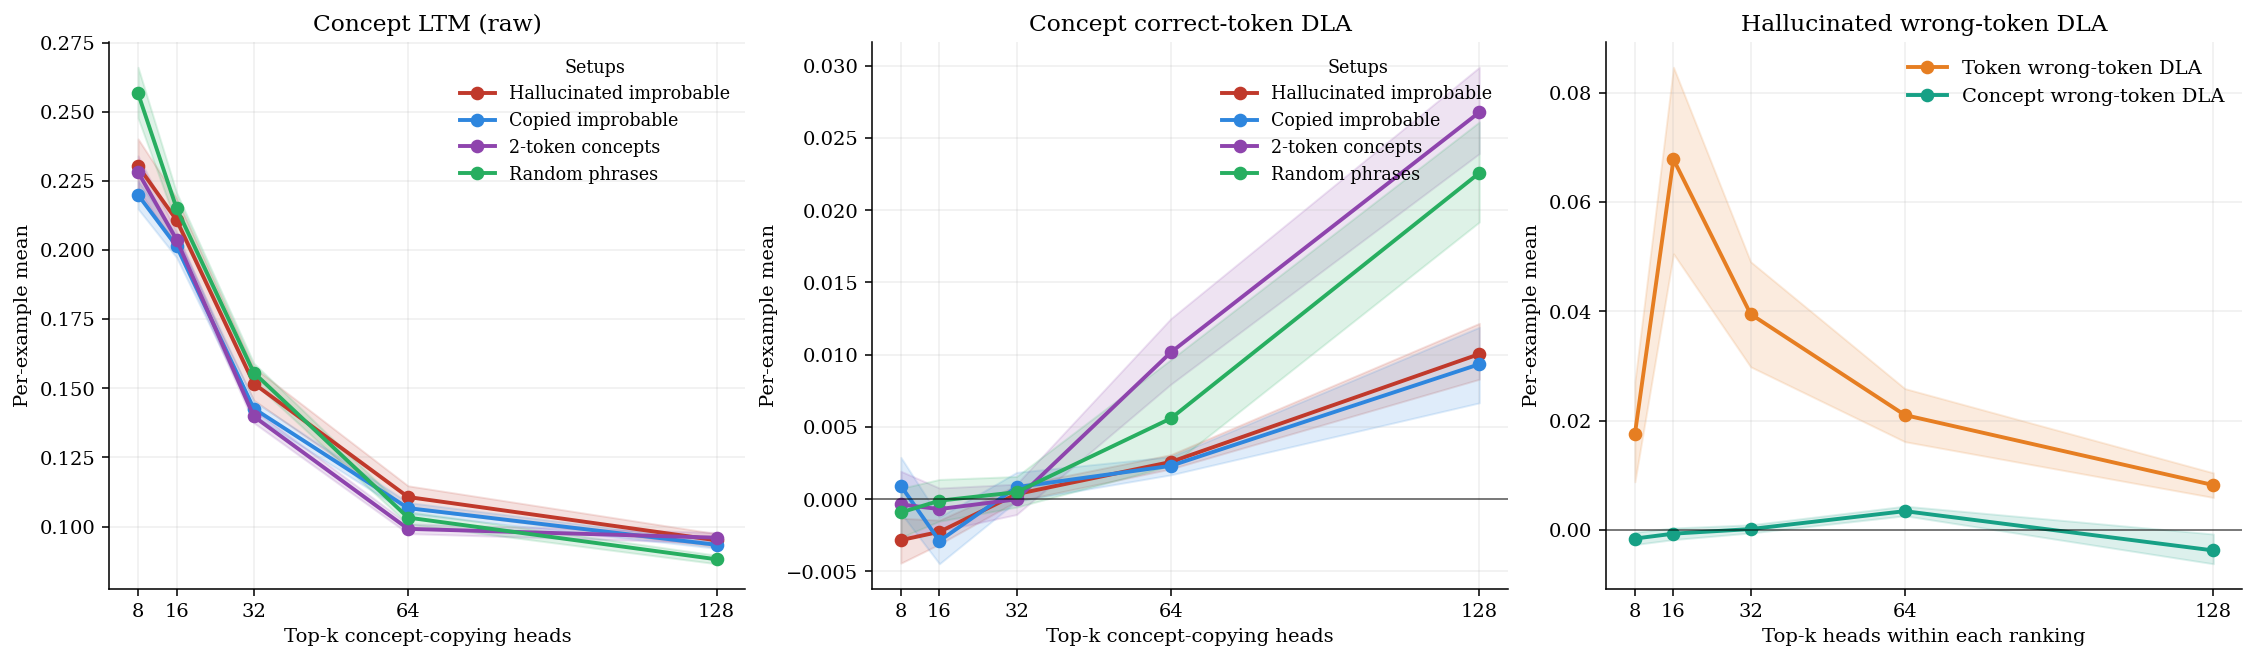

In [23]:
fig, axes, sweep = h1.plot_concept_k_sweep(CACHE, ks=(8, 16, 32, 64, 128))
display(sweep.round(6))

(<Figure size 1680x784 with 2 Axes>,
 array([<Axes: title={'center': 'Top-32 concept-head LTM'}, ylabel='Per-example mean'>,
        <Axes: title={'center': 'Top-32 concept-head correct-token DLA'}, ylabel='Per-example mean'>],
       dtype=object))

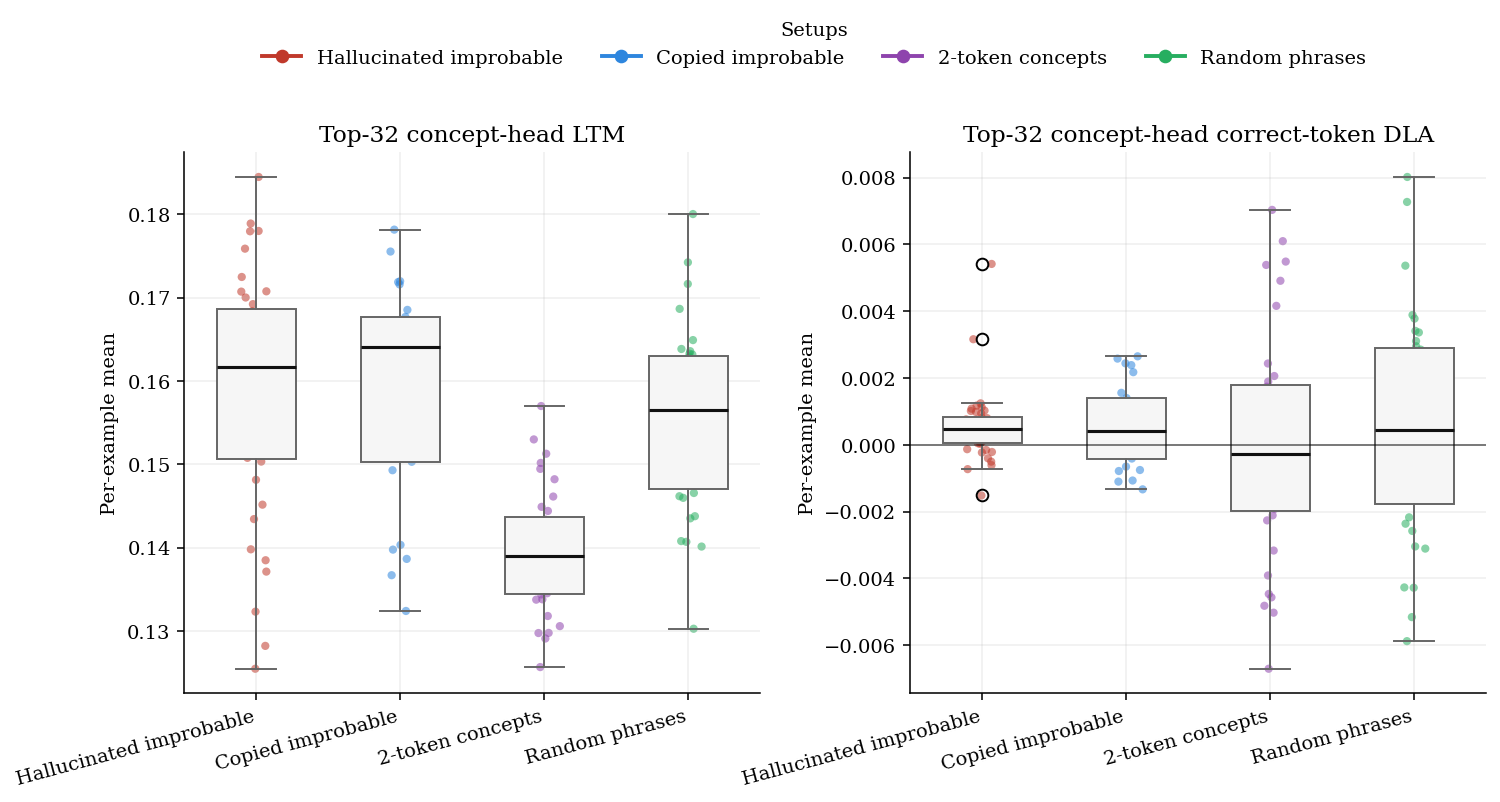

In [12]:
h1.plot_concept_distribution_panels(CACHE, DEFAULT_TOP_K)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 concept heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

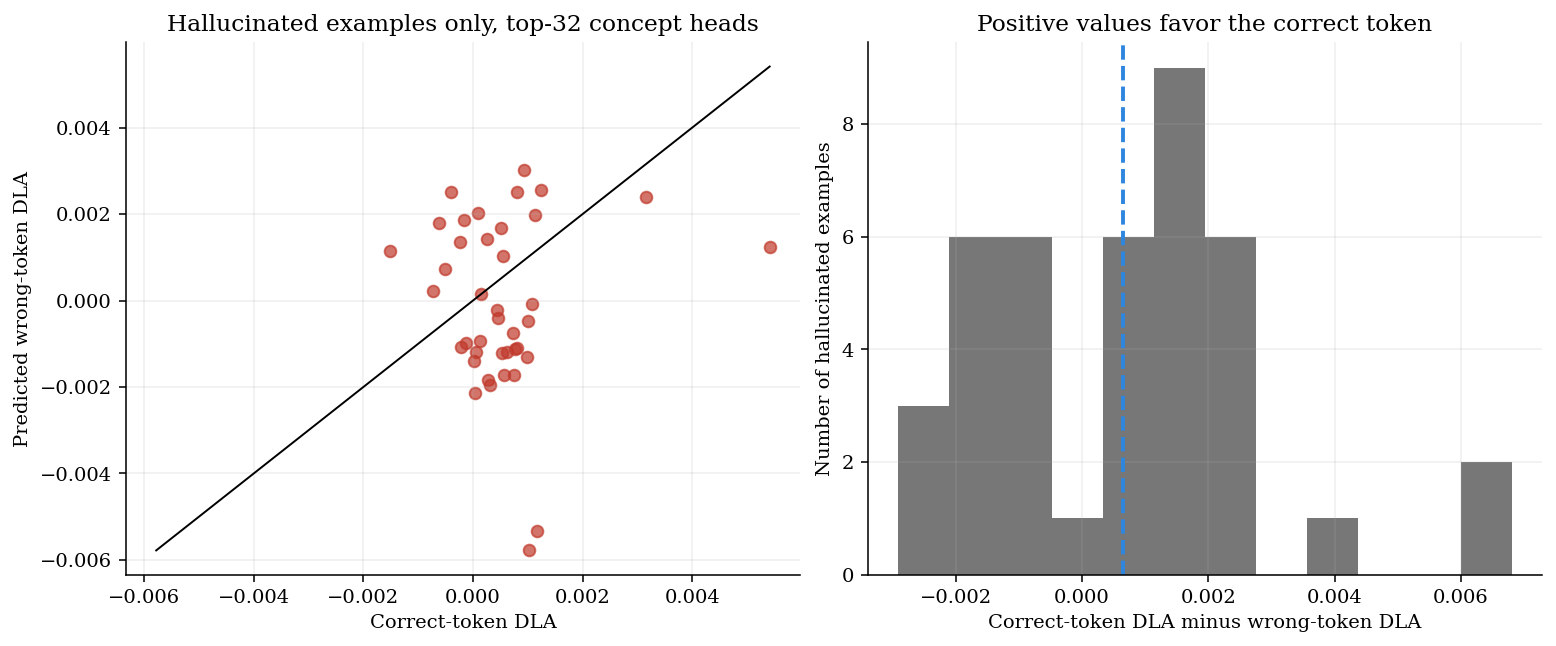

In [13]:
h1.plot_concept_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

(<Figure size 1890x784 with 4 Axes>,
 array([<Axes: title={'center': 'Top-16 concept heads: LTM'}>,
        <Axes: title={'center': 'Top-16 concept heads: DLA'}>],
       dtype=object))

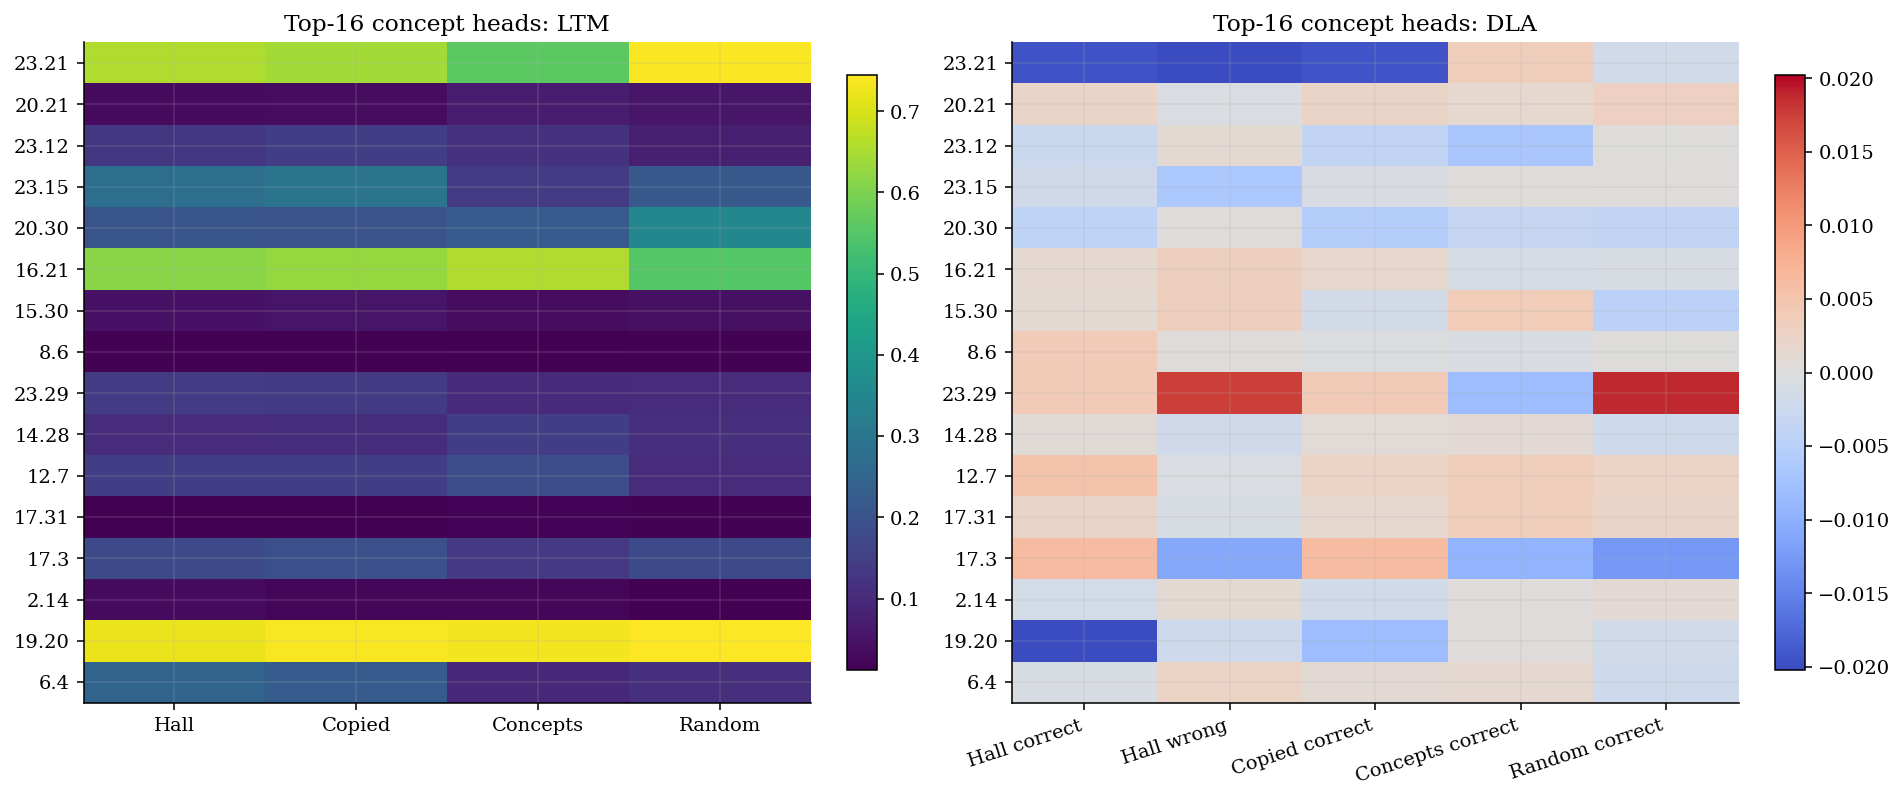

In [16]:
h1.plot_concept_head_heatmap(CACHE, top_k=16)

In [ ]:
SAVE_DIR = ROOT / "scripts" / "qwen_concept_head_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_concept_k_sweep(
    CACHE, ks=(8, 16, 32, 64, 128), save_path=SAVE_DIR / "concept_k_sweep.png"
)
_ = h1.plot_concept_distribution_panels(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "concept_distributions.png"
)
_ = h1.plot_concept_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "concept_hallucinated_dla_pair.png"
)
_ = h1.plot_concept_head_heatmap(
    CACHE, top_k=16, save_path=SAVE_DIR / "concept_top_heads.png"
)
SAVE_DIR